## Global Terrorism Data — ML Notebook (5 Algorithms)

This notebook uses `Global Terrorism Data.csv` and implements:

1. Linear Regression (predict `nkill`)
2. Logistic Regression (predict `success`)
3. K-Nearest Neighbors (predict `success`)
4. SVM (predict `success`)
5. PCA (numeric feature dimensionality reduction)

> Notes:
> - Many GTD-style datasets use `-9`, `-99`, `-999` as missing/unknown codes. We convert them to `NaN`.
> - Some models can be slow on the full dataset; the notebook includes optional sampling controls.


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

import matplotlib.pyplot as plt


In [5]:
DATA_PATH = '/content/drive/MyDrive/Global_Terrorism_Data.csv'

# Optional: set a smaller sample to make KNN/SVM/PCA faster.
# Use None for full dataset.
SAMPLE_N = 30000  # change to None for full dataset
RANDOM_STATE = 42

missing_codes = {-9, -99, -999, -9999}

df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin1')

# Convert common missing codes to NaN (only for numeric columns after coercion).
# We also treat empty strings as NaN.
df = df.replace({"": np.nan})

print("shape:", df.shape)
df.head(3)


shape: (181691, 135)


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [6]:
# Basic cleaning

df_work = df.copy()

# Coerce a handful of columns we will use into numeric (errors -> NaN)
num_cols_to_coerce = [
    "iyear",
    "imonth",
    "iday",
    "latitude",
    "longitude",
    "success",
    "suicide",
    "multiple",
    "property",
    "nperps",
    "nkill",
    "nwound",
]

for c in num_cols_to_coerce:
    if c in df_work.columns:
        df_work[c] = pd.to_numeric(df_work[c], errors="coerce")

# Replace missing codes in numeric columns
for c in num_cols_to_coerce:
    if c in df_work.columns:
        df_work.loc[df_work[c].isin(missing_codes), c] = np.nan

# Optional row sampling (keeps class balance reasonably if shuffled)
if SAMPLE_N is not None and SAMPLE_N < len(df_work):
    df_work = df_work.sample(n=SAMPLE_N, random_state=RANDOM_STATE)

print("work shape:", df_work.shape)

# Quick look at missingness in the main numeric columns
pd.DataFrame({
    "missing_%": (df_work[num_cols_to_coerce].isna().mean() * 100).round(2)
}).sort_values("missing_%", ascending=False)


work shape: (30000, 135)


,missing_%
nperps,84.39
property,11.69
nwound,8.70
nkill,5.46
longitude,2.47
latitude,2.47
iyear,0.00
imonth,0.00
iday,0.00
multiple,0.00


## Feature setup

We’ll build:
- A **regression** task: predict `nkill` (number killed)
- A **classification** task: predict `success` (0/1)

For KNN/PCA we use **numeric-only** features (fast + dense). For Logistic Regression and SVM we also include a few categorical text columns using one-hot encoding.


In [7]:
# Choose a small, reasonable set of features
numeric_features_base = [
    "iyear",
    "imonth",
    "iday",
    "latitude",
    "longitude",
    "suicide",
    "multiple",
    "property",
    "nperps",
]

categorical_features_base = [
    "country_txt",
    "region_txt",
    "attacktype1_txt",
    "targtype1_txt",
    "weaptype1_txt",
]

numeric_features = [c for c in numeric_features_base if c in df_work.columns]
categorical_features = [c for c in categorical_features_base if c in df_work.columns]

print("numeric_features:", numeric_features)
print("categorical_features:", categorical_features)

# Preprocessors
numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess_num_only = ColumnTransformer(
    transformers=[("num", numeric_preprocess, numeric_features)],
    remainder="drop",
)

preprocess_num_cat = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, numeric_features),
        ("cat", categorical_preprocess, categorical_features),
    ],
    remainder="drop",
)


numeric_features: ['iyear', 'imonth', 'iday', 'latitude', 'longitude', 'suicide', 'multiple', 'property', 'nperps']
categorical_features: ['country_txt', 'region_txt', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt']


## 1) Linear Regression (predict `nkill`)


In [14]:
target_reg = "nkill"
if target_reg not in df_work.columns:
    raise ValueError(f"Column {target_reg!r} not found in CSV")

reg_df = df_work[df_work[target_reg].notna()].copy()
X_reg = reg_df[numeric_features + categorical_features]
y_reg = reg_df[target_reg]

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

linreg_model = Pipeline(steps=[
    ("preprocess", preprocess_num_cat),
    ("model", LinearRegression()),
])

linreg_model.fit(X_train, y_train)

y_pred = linreg_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression results")
print("- RMSE:", round(rmse, 4))
print("- MAE :", round(mae, 4))
print("- R^2 :", round(r2, 4))


Linear Regression results
- RMSE: 10.6766
- MAE : 3.028
- R^2 : 0.0538


## 2) Logistic Regression (predict `success`)


In [9]:
target_clf = "success"
if target_clf not in df_work.columns:
    raise ValueError(f"Column {target_clf!r} not found in CSV")

clf_df = df_work[df_work[target_clf].notna()].copy()

# Avoid leaking post-event severity into 'success' prediction
leak_cols = [c for c in ["nkill", "nwound"] if c in clf_df.columns]
feature_cols_clf = [c for c in (numeric_features + categorical_features) if c not in leak_cols and c != target_clf]

X_clf = clf_df[feature_cols_clf]
y_clf = clf_df[target_clf].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

logreg_model = Pipeline(steps=[
    ("preprocess", preprocess_num_cat),
    ("model", LogisticRegression(max_iter=2000, n_jobs=None)),
])

logreg_model.fit(X_train, y_train)

y_pred = logreg_model.predict(X_test)

# roc_auc needs probability for class 1
if hasattr(logreg_model.named_steps["model"], "predict_proba"):
    y_proba = logreg_model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
else:
    auc = np.nan

print("Logistic Regression results")
print("- Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("- Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("- Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 4))
print("- F1       :", round(f1_score(y_test, y_pred, zero_division=0), 4))
print("- ROC AUC  :", round(float(auc), 4) if np.isfinite(auc) else "n/a")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, zero_division=0))


Logistic Regression results
- Accuracy : 0.9068
- Precision: 0.9165
- Recall   : 0.9852
- F1       : 0.9496
- ROC AUC  : 0.8411

Classification report:

              precision    recall  f1-score   support

           0       0.69      0.27      0.39       655
           1       0.92      0.99      0.95      5345

    accuracy                           0.91      6000
   macro avg       0.80      0.63      0.67      6000
weighted avg       0.89      0.91      0.89      6000



## 3) K-Nearest Neighbors (predict `success`, numeric-only)


In [10]:
X_clf_num = clf_df[numeric_features]
y_clf_num = clf_df[target_clf].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_clf_num, y_clf_num, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf_num
)

knn_model = Pipeline(steps=[
    ("preprocess", preprocess_num_only),
    ("model", KNeighborsClassifier(n_neighbors=15)),
])

knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)

print("KNN results")
print("- Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("- Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("- Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 4))
print("- F1       :", round(f1_score(y_test, y_pred, zero_division=0), 4))


KNN results
- Accuracy : 0.8903
- Precision: 0.8973
- Recall   : 0.9903
- F1       : 0.9415


## 4) SVM (predict `success`)

We use a **linear SVM** (`LinearSVC`) because it scales much better than an RBF SVM for large datasets.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

svm_model = Pipeline(steps=[
    ("preprocess", preprocess_num_cat),
    ("model", LinearSVC()),
])

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("Linear SVM results")
print("- Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("- Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("- Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 4))
print("- F1       :", round(f1_score(y_test, y_pred, zero_division=0), 4))


Linear SVM results
- Accuracy : 0.9078
- Precision: 0.9131
- Recall   : 0.9908
- F1       : 0.9504


## 5) PCA (numeric-only)

We standardize numeric features, then:
- Plot explained variance ratio (how much information each component keeps)
- Show a 2D PCA projection colored by `success`


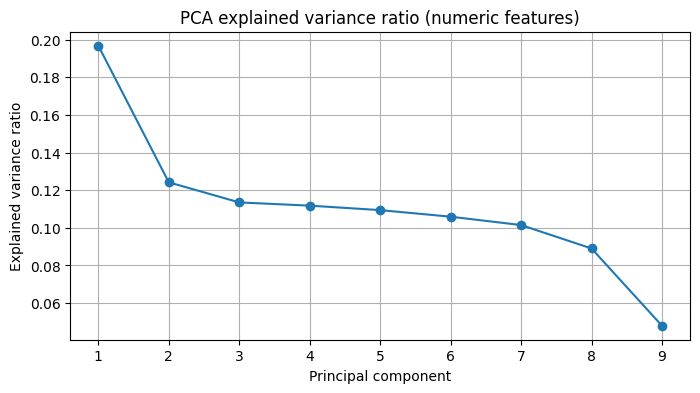

Cumulative explained variance (first 9 components): 1.0


In [12]:
# Prepare numeric matrix
X_num = clf_df[numeric_features]
y_success = clf_df[target_clf].astype(int)

# Preprocess (impute + scale) and then PCA
X_num_scaled = preprocess_num_only.fit_transform(X_num)

# Explained variance plot (first up to 20 components)
max_components = min(20, X_num_scaled.shape[1])
pca_full = PCA(n_components=max_components, random_state=RANDOM_STATE)
pca_full.fit(X_num_scaled)

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, max_components + 1), pca_full.explained_variance_ratio_, marker="o")
plt.title("PCA explained variance ratio (numeric features)")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.grid(True)
plt.show()

print("Cumulative explained variance (first", max_components, "components):",
      round(float(np.sum(pca_full.explained_variance_ratio_)), 4))


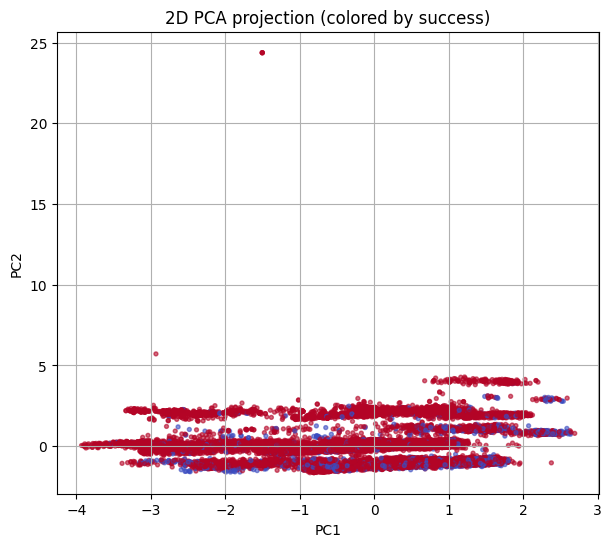

2D explained variance: [0.1968 0.1242]


In [13]:
# 2D PCA projection
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_num_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y_success,
    cmap="coolwarm",
    s=8,
    alpha=0.6,
)
plt.title("2D PCA projection (colored by success)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

print("2D explained variance:", np.round(pca_2d.explained_variance_ratio_, 4))
